Lib import

In [4]:
import numpy as np
import matplotlib.pyplot as plt

Understanding Neurons and Activation Functions

A neural network is composed of multiple layers of neurons, where each neuron performs a simple computation to process input data.
Basic Neuron Computation

A neuron receives inputs (features), applies a linear transformation, and then passes the result through an activation function.
For example, predicting house prices using features like size, bedrooms, and location:

Image 15.02.26 at 19.10.heic

Neuron

inputs, features (house price, n of bedrooms, location)

### **Step 2.1: Define a Neuron with a Linear Function**
A single neuron computes a weighted sum of inputs and adds a bias:

y^ = w ⋅ X + β

if n features:


y^ = w1 ⋅ X1 + w2 ⋅ X2 + ... wn ⋅ Xn + β

In [5]:
def neuron(inputs, weights, bias):
  return np.dot(inputs, weights) + bias

In [6]:
# Example
inputs = np.array([2000, 3, 1]) # house price, n of bedrooms, location(zip code)

weights = np.array([0.1, 50, 100])

bias = 2000 # base price of property in that city

In [7]:
output = neuron(inputs, weights, bias)

In [8]:
print(f'Neuron output: {output}')

Neuron output: 2450.0


### **Step 2.2: Apply an Activation Function**
Activation functions introduce non-linearity into the model.
Common activation functions include:
- **Sigmoid**: Used for probabilities.
- **ReLU (Rectified Linear Unit)**: Helps in deep networks by preventing vanishing gradients.

#### **ReLU Activation Function**

In [9]:
def relu(x):
  return np.maximum(0, x)

In [10]:
activated_output = relu(output)

In [11]:
print(f'Activated output using ReLu: {activated_output}')

Activated output using ReLu: 2450.0


So full neuron:
y = \phi(w \cdot x + b)


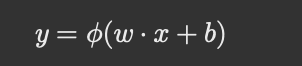

Simple NN

In [12]:
def simple_nn(inputs, weights, bias):
  layer_output = relu(np.dot(inputs, weights) + bias)
  return layer_output

In [13]:
simple_nn(inputs, weights, bias)

np.float64(2450.0)

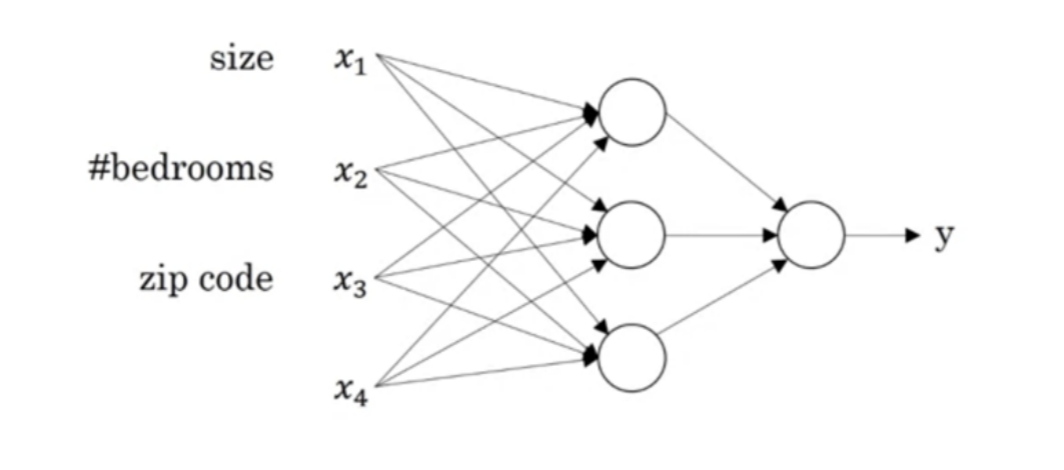

Input (3)

↓

Hidden layer (2 neurons)

↓

Output layer (1 neuron)

## Question from the class: do we not need activation function on the output layer?

Answer: Output activation = depends on what you want to predict.
We don’t always add activation on the output because sometimes the raw linear value is exactly what we need.

*No in the case of Regression e.g. house price, stock value*
We want a real number there (-∞, +∞)

This is not a rule!!! If we have multi-class classification or binary classification task, we do apply sigmoid on the last layer. Furthermore, sometimes activation function is merged into loss, e.g.

•	Sigmoid + BinaryCrossEntropy

•	Softmax + CrossEntropy

In [14]:
def simple_nn(inputs, weights_hidden, bias_hidden, weights_output, bias_output):
  # hidden layer
  hidden_layer_output = relu(np.dot(inputs, weights_hidden) + bias_hidden)

  final_output = np.dot(hidden_layer_output, weights_output) + bias_output

  return final_output

In [15]:
inputs = np.array([2000, 3, 1])

weights_hidden = np.array([
    [0.2, 0.5],
    [0.3, 0.7],
    [0.1, 0.4]
]) # shape (3, 2), 2 neurons

# weights_hidden = np.array([
#     [0.2, 0.5, 0.8],
#     [0.3, 0.7, 0.3],
#     [0.1, 0.4, 0.9]
# ]) # shape (3, 3), 3 neurons, for replicating the image above

In [16]:
bias_hidden = np.array([1.0, 1.0]) # shape (2,) -> I have 2 neurons

In [17]:
weights_output = np.array([
    [0.6],
    [0.9]
]) # shape (2, 1)

bias_output = np.array([5000]) # shape (1,)

In [18]:
nn_output = simple_nn(inputs, weights_hidden, bias_hidden, weights_output, bias_output)

print(f'Predicted House price: {nn_output}')

Predicted House price: [6144.35]


new nn, 2 hidden, 1 output layer

Input (3)


↓

Hidden Layer 1 (4 neurons)

↓

Hidden Layer 2 (3 neurons)

↓

Output Layer (1 neuron)

Each neuron applies activation individually, and the resulting 1D vector of activated neurons becomes the input to the next layer.

In [19]:
def simple_nn(inputs,
              W1, b1,
              W2, b2,
              W3, b3):

  # 1st hidden layer
  a1 = relu(np.dot(inputs, W1) + b1)

  # 2nd hidden layer
  a2 = relu(np.dot(a1, W2) + b2)

  # output layer
  output = np.dot(a2, W3) + b3

  return output

In [20]:
# example shapes

# 3 inputs -> 4 neurons
W1 = np.random.randn(3, 4) # 4 neurons
b1 = np.random.randn(4)

# 4 neurons -> 3 neurons
W2 = np.random.randn(4, 3)
b2 = np.random.randn(3)

# 3 neurons -> 1 output
W3 = np.random.randn(3, 1)
b3 = np.random.randn(1,)

In [21]:
prediction = simple_nn(inputs, W1, b1, W2, b2, W3, b3)

print(prediction)

-385.9662079287255


In [22]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

In [23]:
from PIL import Image

In [24]:
image = Image.open('/content/drive/MyDrive/Deep Learning and Artificial Neural Networks/Excercise 1/cat.png').resize((64, 64))

Image:

W = 64px
H = 64px
RGB = 3

WxHxRGB = 64x64x3 = 12288

In [25]:
image_array = np.array(image)

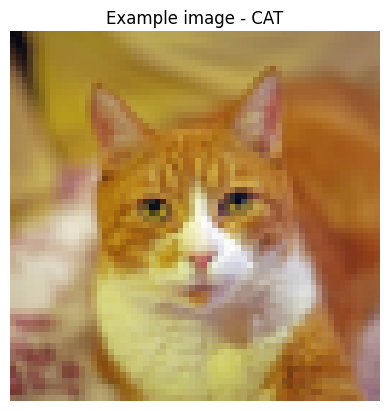

Image shape (width, height, channels): (64, 64, 4)


In [26]:
plt.imshow(image)
plt.title('Example image - CAT')
plt.axis('off')
plt.show()

# image shape
print(f'Image shape (width, height, channels): {image_array.shape}')

Our PIL Image library recognized that this image is not RGB, but rather RGBA - it has an alpha, transparency channel.

We are usually working with RGB = 3 channels or grayscale = 1 channel

Convert into a feature vector

1D vector size (12288, 1)

12288 features
1 sample (1 image)

In [27]:
X = image_array.reshape(-1, 1) # unrolling into a single vector - used in fully connected NNs
# (number_of_pixels, 1) - each pixel = one feature
# Example with a small image:
# img = np.array([
#     [1, 2],
#     [3, 4]
# ]), shape (2, 2)

# then we flatten img.reshape(-1, 1)
# Result: [[1],
        #  [2],
        #  [3],
        #  [4]], shape (4, 1)
# it means one column → one sample, features x samples
# from grid of pixels ->  long list of pixels
# Because dense layers compute:

# y = W x + b

# which requires a vector. This happens in CNNs before dense layers too.

In [33]:
n_features = X.shape[0]

W = np.random.randn(n_features, 1) * 0.01
b = 0

In [34]:
z = np.dot(W.T, X) + b
activated_z = sigmoid(z)

Why do we transpose W (weights)?

vector orientation (row vs column)

We do this so matrix dimensions match for multiplication.

We defined the following:
n_features = X.shape[0]
W.shape = (n_features, 1)

This means that W is a column vector:
W =
[ w1
  w2
  w3 ]

Since we used n_features = X.shape[0], our X.shape = (n_features, m)

So:
* rows = features
* columns = samples

If we transpose W:

our shapes are:

* from W = (n_features, 1) -> W.T = (1, n_features)
* X   = (n_features, m)

Result is: z = (1, m)

Meaning: one prediction per sample.



This could be avoided if we reshaped our X (1, -1) instead of (-1, 1) in the frist place but a common practice says that we store as (features, samples) and not (samples, features). Linear algebra textbooks use column vectors.

In [35]:
print(f'Predicted probability of an image representing a cat is: {activated_z}')

Predicted probability of an image representing a cat is: [[0.99975792]]
